In [1]:
!pip install -q diffusers accelerate torchvision matplotlib tqdm

In [2]:
from google.colab import drive
import os
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from diffusers import UNet2DModel

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
import os
import tarfile

from google.colab import drive
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

data_root = "/kaggle/input/datasets/vittoriog26/dataset-cifar/DATASETS"

archive_path = os.path.join(
    data_root,
    "cifar-10-python.tar.gz"
)

extract_path = os.path.join(
    data_root,
    "cifar-10-batches-py"
)

# If the compressed file is present but the extracted folder is not
if os.path.isfile(archive_path) and not os.path.isdir(extract_path):
    print("Estrazione del dataset da Google Drive...")

    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(path=data_root)

# Try loading the dataset
try:

    dataset = torchvision.datasets.CIFAR10(
        root=data_root,
        train=True,
        download=False,
        transform=transform
    )

    print("Dataset CIFAR-10 loaded")

except RuntimeError:

    print("Dataset not founf. Download...")

    dataset = torchvision.datasets.CIFAR10(
        root=data_root,
        train=True,
        download=True,
        transform=transform
    )

    print("Dataset downloaded and saved on Google Drive.")

dataloader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print(f"Number of images: {len(dataset)}")

Dataset CIFAR-10 loaded
Number of images: 50000


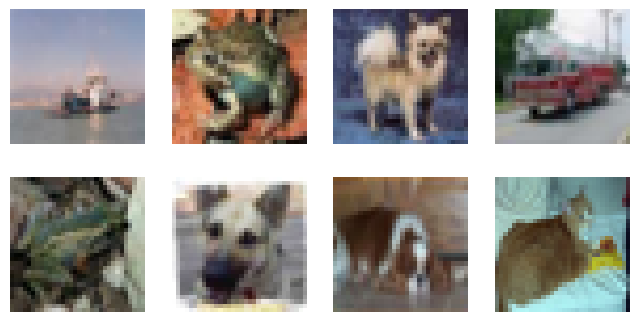

In [5]:
images, _ = next(iter(dataloader))

fig, axes = plt.subplots(2, 4, figsize=(8,4))

for ax, img in zip(axes.flatten(), images[:8]):
    img = img.permute(1,2,0)
    img = img * 0.5 + 0.5
    ax.imshow(img)
    ax.axis("off")

plt.show()

In [6]:
# diffusion schedule

T = 1000

beta = torch.linspace(
    1e-4,
    0.02,
    T,
    device=device
)

alpha = 1.0 - beta

alpha_bar = torch.cumprod(
    alpha,
    dim=0
)

In [7]:
# unet

model = UNet2DModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 256),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    )
)

model = model.to(device)

print(
    f"Parameters: "
    f"{sum(p.numel() for p in model.parameters()):,}"
)

Parameters: 15,724,931


In [8]:
# optimizer

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)

criterion = nn.MSELoss()

In [9]:
# forward diffusion

def add_noise(x0, t):

    noise = torch.randn_like(x0)

    alpha_bar_t = alpha_bar[t].view(
        -1, 1, 1, 1
    )

    xt = (
        torch.sqrt(alpha_bar_t) * x0
        +
        torch.sqrt(1 - alpha_bar_t) * noise
    )

    return xt, noise

In [10]:
def show_samples(samples):

    samples = samples.cpu()

    samples = (
        samples.clamp(-1, 1) + 1
    ) / 2

    fig, axes = plt.subplots(
        4, 4,
        figsize=(8, 8)
    )

    for ax, img in zip(
        axes.flatten(),
        samples
    ):

        img = img.permute(1, 2, 0)

        ax.imshow(
            img,
            interpolation="bicubic"
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [11]:
# training

EPOCHS = 50 # 50 ###############################################################

In [12]:
# training

for epoch in range(EPOCHS):

    model.train()

    pbar = tqdm(dataloader)

    running_loss = 0

    for images, _ in pbar:

        images = images.to(device)

        batch_size = images.size(0)

        t = torch.randint(
            0,
            T,
            (batch_size,),
            device=device
        ).long()

        xt, noise = add_noise(
            images,
            t
        )

        pred_noise = model(
            xt,
            t
        ).sample

        loss = criterion(
            pred_noise,
            noise
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        pbar.set_description(
            f"Epoch {epoch+1}/{EPOCHS}"
        )

        pbar.set_postfix(
            loss=loss.item()
        )

    print(
        f"Epoch {epoch+1}: "
        f"{running_loss/len(dataloader):.4f}"
    )

    #if (epoch + 1) % 5 == 0:

      #  samples = sample(
      #      model,
      #      n_images=16
      #  )

      #  show_samples(samples)

  0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1: 0.1071


  0%|          | 0/391 [00:00<?, ?it/s]

Epoch 2: 0.0479


  0%|          | 0/391 [00:00<?, ?it/s]

...

  0%|          | 0/391 [00:00<?, ?it/s]

Epoch 49: 0.0312


  0%|          | 0/391 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bc2cab3b9c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bc2cab3b9c0>
if w.is_alive():Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

       self._shutdown_workers() 
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
     if w.is_alive():  
^ ^^ ^  ^  ^ ^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'^
^^ ^ ^  ^  ^ 
  File "/usr/lib

Epoch 50: 0.0311


In [13]:
torch.save(
    model.state_dict(),
    "/kaggle/working/ddpm_cifar10.pth"
)

In [14]:
# sampling

@torch.no_grad()
def sample(model, n_images=16):

    model.eval()

    x = torch.randn(
        n_images,
        3,
        32,
        32,
        device=device
    )

    for t in tqdm(
        reversed(range(T)),
        total=T
    ):

        tt = torch.full(
            (n_images,),
            t,
            device=device,
            dtype=torch.long
        )

        predicted_noise = model(
            x,
            tt
        ).sample

        alpha_t = alpha[t]
        alpha_bar_t = alpha_bar[t]
        beta_t = beta[t]

        if t > 0:
            z = torch.randn_like(x)
        else:
            z = torch.zeros_like(x)

        x = (
            1 / torch.sqrt(alpha_t)
        ) * (
            x
            -
            (
                (1 - alpha_t)
                /
                torch.sqrt(
                    1 - alpha_bar_t
                )
            )
            * predicted_noise
        ) + torch.sqrt(beta_t) * z

    return x

In [15]:
def show_samples(samples):

    samples = samples.cpu()

    samples = (
        samples.clamp(-1, 1) + 1
    ) / 2

    fig, axes = plt.subplots(
        4, 4,
        figsize=(8, 8)
    )

    for ax, img in zip(
        axes.flatten(),
        samples
    ):

        img = img.permute(1, 2, 0)

        ax.imshow(
            img
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

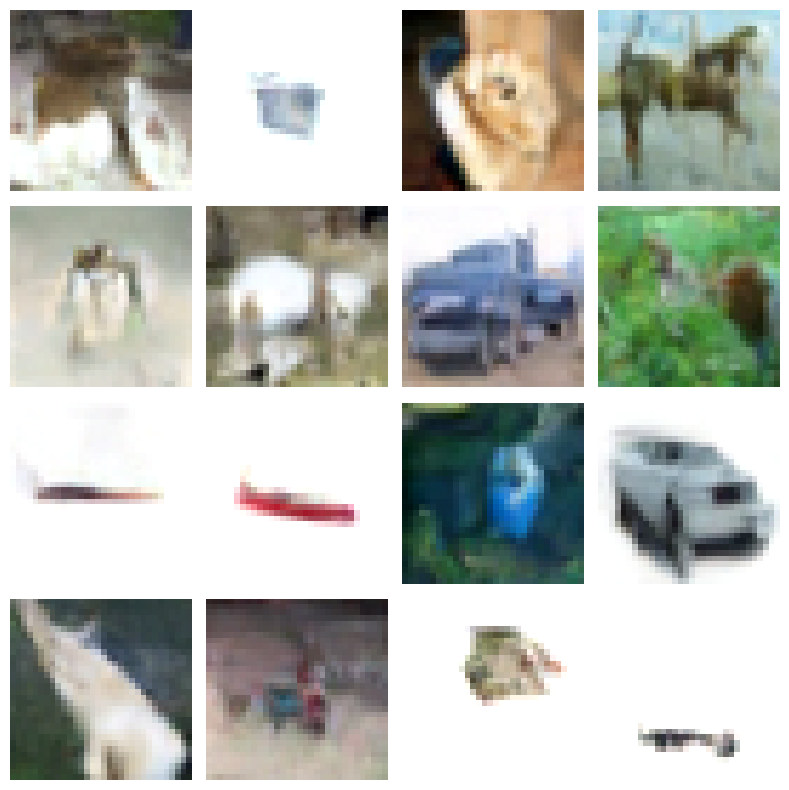

In [16]:
# images generation

samples = sample(
    model,
    n_images=16
)

show_samples(samples)

# PRUNING


In [17]:
!pip install torch-pruning
import torch
import torch_pruning as tp
import copy
import torch.nn.utils.prune as prune

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.4 MB/s eta 0:00:00


In [18]:
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

In [19]:
from google.colab import drive
import torch
from diffusers import UNet2DModel
import copy

# Monta Google Drive
#drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreates the model
model = UNet2DModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 256),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    )
).to(device)

# Load weights
model_path = "/kaggle/working/ddpm_cifar10.pth"
model.load_state_dict(torch.load(model_path, map_location=device))

print("Model successfully loaded.")



Model successfully loaded.


In [20]:
example_inputs = {
    "sample": torch.randn(1, 3, 32, 32).to(device),
    "timestep": torch.tensor([1]).to(device)
}

pruned_model = copy.deepcopy(model)

In [21]:
import torch
import torch_pruning as tp

ignored_layers = []


for module in pruned_model.modules():

    # Diffusers attention blocks
    if module.__class__.__name__ in [
        "Attention",
        "AttnDownBlock2D",
        "AttnUpBlock2D",
        "Transformer2DModel",
    ]:
        ignored_layers.extend(list(module.modules()))

# removes any duplicates
ignored_layers = list(set(ignored_layers))

################
ignored_layers.extend([
    pruned_model.conv_in,
    pruned_model.conv_out,
])

for name, module in pruned_model.named_modules():
    if "conv_shortcut" in name:
        ignored_layers.append(module)

    if "upsamplers" in name:
        ignored_layers.append(module)

ignored_layers = list(set(ignored_layers))
###############



print(f"Ignored {len(ignored_layers)} modules")

Ignored 113 modules


In [22]:
pruner = tp.pruner.MagnitudePruner(
    pruned_model,
    example_inputs,
    importance=tp.importance.MagnitudeImportance(p=2),
    pruning_ratio=0.4,########################################################################
    ignored_layers=ignored_layers,
)

pruner.step()

In [23]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

print(f"Original model parameters: {count_params(model):,}")
print(f"Pruned model parameters: {count_params(pruned_model):,}")


Original model parameters: 15,724,931
Pruned model parameters: 12,817,190


In [24]:
# Better visualization

def print_conv_layers(model, title="Model"):
    print(f"\n{'=' * 60}")
    print(title)
    print(f"{'=' * 60}")

    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Conv2d):
            print(
                f"{name:45}"
                f"{module.in_channels:4} -> {module.out_channels:4} "
                f"k={module.kernel_size}"
            )

print_conv_layers(model, "MODEL")

print_conv_layers(pruned_model, "PRUNED MODEL")


MODEL
conv_in                                         3 ->   64 k=(3, 3)
down_blocks.0.resnets.0.conv1                  64 ->   64 k=(3, 3)
down_blocks.0.resnets.0.conv2                  64 ->   64 k=(3, 3)
down_blocks.0.resnets.1.conv1                  64 ->   64 k=(3, 3)
down_blocks.0.resnets.1.conv2                  64 ->   64 k=(3, 3)
down_blocks.0.downsamplers.0.conv              64 ->   64 k=(3, 3)
down_blocks.1.resnets.0.conv1                  64 ->  128 k=(3, 3)
down_blocks.1.resnets.0.conv2                 128 ->  128 k=(3, 3)
down_blocks.1.resnets.0.conv_shortcut          64 ->  128 k=(1, 1)
down_blocks.1.resnets.1.conv1                 128 ->  128 k=(3, 3)
down_blocks.1.resnets.1.conv2                 128 ->  128 k=(3, 3)
down_blocks.1.downsamplers.0.conv             128 ->  128 k=(3, 3)
down_blocks.2.resnets.0.conv1                 128 ->  256 k=(3, 3)
down_blocks.2.resnets.0.conv2                 256 ->  256 k=(3, 3)
down_blocks.2.resnets.0.conv_shortcut         128 ->  2

# FINE-TUNING

In [25]:
import copy
from google.colab import drive
import os
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from diffusers import UNet2DModel

In [26]:
import os
import tarfile

from google.colab import drive
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

data_root = "/kaggle/input/datasets/vittoriog26/dataset-cifar/DATASETS"

archive_path = os.path.join(
    data_root,
    "cifar-10-python.tar.gz"
)

extract_path = os.path.join(
    data_root,
    "cifar-10-batches-py"
)

if os.path.isfile(archive_path) and not os.path.isdir(extract_path):
    print("Extracting the dataset...")

    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(path=data_root)

try:

    dataset = torchvision.datasets.CIFAR10(
        root=data_root,
        train=True,
        download=False,
        transform=transform
    )

    print("Dataset CIFAR-10 loaded from Google Drive.")

except RuntimeError:

    print("Dataset not found. Download...")

    dataset = torchvision.datasets.CIFAR10(
        root=data_root,
        train=True,
        download=True,
        transform=transform
    )

    print("Dataset downloaded and saved.")

dataloader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print(f"Number of images: {len(dataset)}")

Dataset CIFAR-10 loaded from Google Drive.
Number of images: 50000


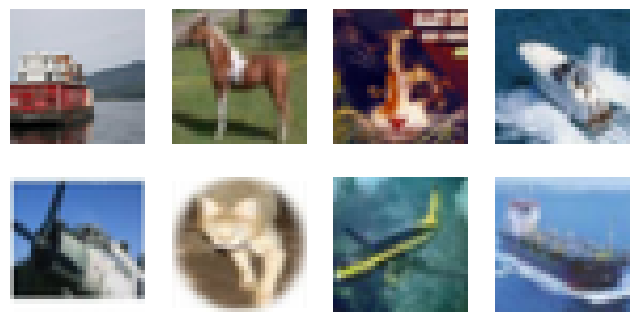

In [27]:
images, _ = next(iter(dataloader))

fig, axes = plt.subplots(2, 4, figsize=(8,4))

for ax, img in zip(axes.flatten(), images[:8]):
    img = img.permute(1,2,0)
    img = img * 0.5 + 0.5
    ax.imshow(img)
    ax.axis("off")

plt.show()

In [28]:
# diffusion schedule

T = 1000

beta = torch.linspace(
    1e-4,
    0.02,
    T,
    device=device
)

alpha = 1.0 - beta

alpha_bar = torch.cumprod(
    alpha,
    dim=0
)

In [29]:
# forward diffusion

def add_noise(x0, t):

    noise = torch.randn_like(x0)

    alpha_bar_t = alpha_bar[t].view(
        -1, 1, 1, 1
    )

    xt = (
        torch.sqrt(alpha_bar_t) * x0
        +
        torch.sqrt(1 - alpha_bar_t) * noise
    )

    return xt, noise

In [30]:
# fine-tuning

finetuned_model = copy.deepcopy(pruned_model)

criterion = torch.nn.MSELoss()

optimizer = torch.optim.AdamW(
    finetuned_model.parameters(),
    lr=5e-5
)



num_epochs = 20 #5-10-20 #####################################################################
for epoch in range(num_epochs):

    finetuned_model.train()

    pbar = tqdm(dataloader)

    running_loss = 0

    for images, _ in pbar:

        images = images.to(device)

        batch_size = images.size(0)

        t = torch.randint(
            0,
            T,
            (batch_size,),
            device=device
        ).long()

        xt, noise = add_noise(
            images,
            t
        )

        pred_noise = finetuned_model(
            xt,
            t
        ).sample

        loss = criterion(
            pred_noise,
            noise
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        pbar.set_description(
            f"Epoch {epoch+1}/{num_epochs}"
        )

        pbar.set_postfix(
            loss=loss.item()
        )

    print(
        f"Epoch {epoch+1}: "
        f"{running_loss/len(dataloader):.4f}"
    )

  0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1: 0.0539


  0%|          | 0/391 [00:00<?, ?it/s]

Epoch 2: 0.0367


  0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch 18: 0.0321


  0%|          | 0/391 [00:00<?, ?it/s]

Epoch 19: 0.0319


  0%|          | 0/391 [00:00<?, ?it/s]

Epoch 20: 0.0313


In [31]:
torch.save(
    finetuned_model,
    "/kaggle/working/ddpm_cifar10_pruned_finetuned.pth"
)

In [32]:
# sampling

@torch.no_grad()
def sample(model, n_images=16):

    model.eval()

    x = torch.randn(
        n_images,
        3,
        32,
        32,
        device=device
    )

    for t in tqdm(
        reversed(range(T)),
        total=T
    ):

        tt = torch.full(
            (n_images,),
            t,
            device=device,
            dtype=torch.long
        )

        predicted_noise = model(
            x,
            tt
        ).sample

        alpha_t = alpha[t]
        alpha_bar_t = alpha_bar[t]
        beta_t = beta[t]

        if t > 0:
            z = torch.randn_like(x)
        else:
            z = torch.zeros_like(x)

        x = (
            1 / torch.sqrt(alpha_t)
        ) * (
            x
            -
            (
                (1 - alpha_t)
                /
                torch.sqrt(
                    1 - alpha_bar_t
                )
            )
            * predicted_noise
        ) + torch.sqrt(beta_t) * z

    return x

In [33]:
def show_samples(samples):

    samples = samples.cpu()

    samples = (
        samples.clamp(-1, 1) + 1
    ) / 2

    fig, axes = plt.subplots(
        4, 4,
        figsize=(8, 8)
    )

    for ax, img in zip(
        axes.flatten(),
        samples
    ):

        img = img.permute(1, 2, 0)

        ax.imshow(
            img
            #interpolation="bicubic"
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

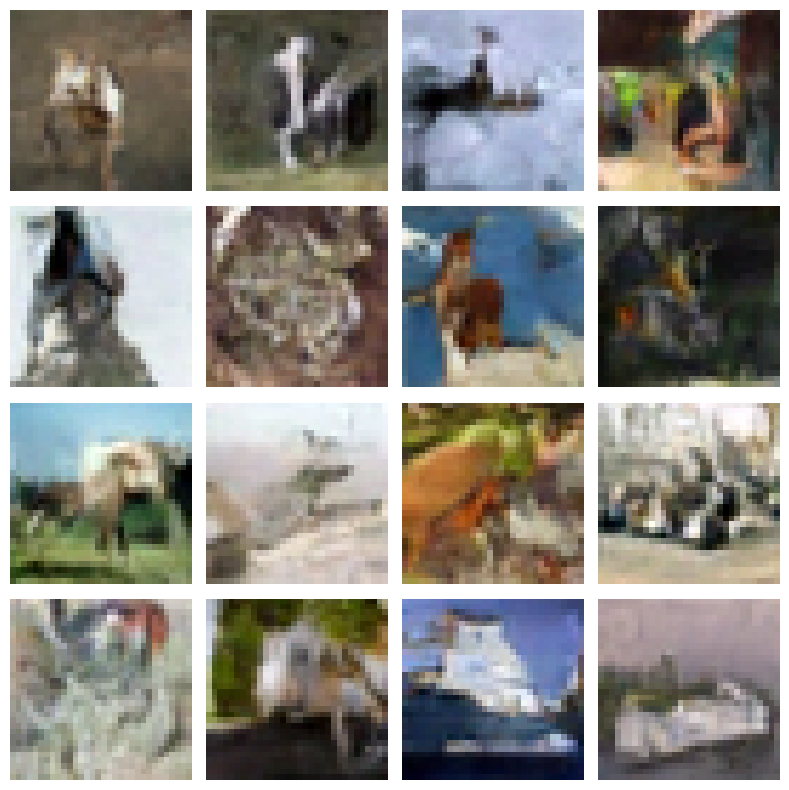

In [34]:
# generazione immagini

samples = sample(
    finetuned_model,
    n_images=16
)

show_samples(samples)

# PRUNING+FINETUNING EVALUATION

In [35]:
import os
import time
import torch
import torch.nn.functional as F
import torch_pruning as tp


def evaluate_model(
    model,
    dataloader,
    example_inputs,
    model_name,
    original_params=None,
    original_macs=None,
):

    device = next(model.parameters()).device
    model.eval()

    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)

    ##########################################################
    # PARAMETERS
    ##########################################################

    params = sum(p.numel() for p in model.parameters())

    print(f"\nNumber of parameters: {params:,}")
    print("Description: total number of trainable parameters.")

    if original_params is not None:

        reduction = 100 * (1 - params / original_params)

        print(f"Reduction of parameters: {reduction:.2f}%")
        print("Description: percentage of parameters eliminated compared to the original model.")

    ##########################################################
    # MODEL DIMENSION
    ##########################################################

    filename = "tmp_model.pth"

    torch.save(model.state_dict(), filename)

    size_mb = os.path.getsize(filename) / (1024 ** 2)

    os.remove(filename)

    print(f"\nModel dimension: {size_mb:.2f} MB")
    print("Description: space occupied by the model's weights.")

    ##########################################################
    # FLOPs / MACs
    ##########################################################

    macs, _ = tp.utils.count_ops_and_params(
        model,
        example_inputs
    )

    print(f"\nMACs: {macs:,}")
    print("Description: number of multiply-accumulate operations required for a forward pass.")

    if original_macs is not None:

        reduction = 100 * (1 - macs / original_macs)

        print(f"MACs reduction: {reduction:.2f}%")
        print("Description: reduction in computational cost compared to the original model.")

    ##########################################################
    # INFERENCE TIME
    ##########################################################

    with torch.no_grad():

        for _ in range(10):
            _ = model(**example_inputs)

        start = time.perf_counter()

        for _ in range(100):

            _ = model(**example_inputs)

        end = time.perf_counter()

    inference_time = (end - start) / 100

    print(f"\nAverage inference time: {1000*inference_time:.2f} ms")
    print("Description: average time required for a model forward pass.")

    ##########################################################
    # MSE
    ##########################################################

    mse = 0

    with torch.no_grad():

        for images, _ in dataloader:

            images = images.to(device)

            t = torch.randint(
                0,
                T,
                (images.size(0),),
                device=device
            ).long()

            xt, noise = add_noise(images, t)

            pred = model(
                xt,
                t
            ).sample

            mse += F.mse_loss(
                pred,
                noise
            ).item()

    mse /= len(dataloader)

    print(f"\nMSE: {mse:.6f}")
    print("Description: mean squared error between the actual noise and the predicted noise.")
    print("Lower values indicate better denoising capability.")

    print("\n" + "=" * 80)

In [36]:
original_params = sum(p.numel() for p in model.parameters())

original_macs, _ = tp.utils.count_ops_and_params(
    model,
    example_inputs
)

evaluate_model(
    model,
    dataloader,
    example_inputs,
    "ORIGINAL MODEL"
)

Warning! No positional inputs found for a module, assuming batch size is 1.

ORIGINAL MODEL

Number of parameters: 15,724,931
Description: total number of trainable parameters.

Model dimension: 60.08 MB
Description: space occupied by the model's weights.
Warning! No positional inputs found for a module, assuming batch size is 1.

MACs: 2,138,378,432.0
Description: number of multiply-accumulate operations required for a forward pass.

Average inference time: 14.00 ms
Description: average time required for a model forward pass.

MSE: 0.031300
Description: mean squared error between the actual noise and the predicted noise.
Lower values indicate better denoising capability.



In [37]:
evaluate_model(
    pruned_model,
    dataloader,
    example_inputs,
    "PRUNED MODEL",
    original_params,
    original_macs
)


PRUNED MODEL

Number of parameters: 12,817,190
Description: total number of trainable parameters.
Reduction of parameters: 18.49%
Description: percentage of parameters eliminated compared to the original model.

Model dimension: 48.99 MB
Description: space occupied by the model's weights.
Warning! No positional inputs found for a module, assuming batch size is 1.

MACs: 1,535,746,979.0
Description: number of multiply-accumulate operations required for a forward pass.
MACs reduction: 28.18%
Description: reduction in computational cost compared to the original model.

Average inference time: 13.51 ms
Description: average time required for a model forward pass.

MSE: 0.452704
Description: mean squared error between the actual noise and the predicted noise.
Lower values indicate better denoising capability.



In [38]:
evaluate_model(
    finetuned_model,
    dataloader,
    example_inputs,
    "PRUNED MODEL + FINE-TUNING",
    original_params,
    original_macs
)


PRUNED MODEL + FINE-TUNING

Number of parameters: 12,817,190
Description: total number of trainable parameters.
Reduction of parameters: 18.49%
Description: percentage of parameters eliminated compared to the original model.

Model dimension: 48.99 MB
Description: space occupied by the model's weights.
Warning! No positional inputs found for a module, assuming batch size is 1.

MACs: 1,535,746,979.0
Description: number of multiply-accumulate operations required for a forward pass.
MACs reduction: 28.18%
Description: reduction in computational cost compared to the original model.

Average inference time: 14.00 ms
Description: average time required for a model forward pass.

MSE: 0.031392
Description: mean squared error between the actual noise and the predicted noise.
Lower values indicate better denoising capability.



# QUANTIZATION

In [39]:
!pip install optimum-quanto

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 3.8 MB/s eta 0:00:00


In [40]:
import copy

quantized_model = copy.deepcopy(finetuned_model)


In [41]:

from optimum.quanto import quantize, freeze, qint8

quantize(quantized_model, weights=qint8)
freeze(quantized_model)

In [42]:
# salvataggio

torch.save(
    quantized_model,
    "/kaggle/working/model_quantized.pth"
)

In [43]:
linear = 0
linear_quantized = 0
conv = 0
conv_quantized = 0

for module in quantized_model.modules():

    cls = module.__class__.__name__

    if cls in ["Linear", "QLinear"]:
        linear += 1

        if cls == "QLinear":
            linear_quantized += 1

    elif cls in ["Conv2d", "QConv2d"]:
        conv += 1

        if cls == "QConv2d":
            conv_quantized += 1

print("===== Quantization Summary =====")
print(f"Linear               : {linear}")
print(f"Quantized Linear     : {linear_quantized}")
print(f"Conv2d               : {conv}")
print(f"Quantized Conv2d     : {conv_quantized}")

print(f"% Quantized Linear   : {100*linear_quantized/linear:.1f}%")
print(f"% Quantized Conv2d   : {100*conv_quantized/conv:.1f}%")

===== Quantization Summary =====
Linear               : 43
Quantized Linear     : 43
Conv2d               : 51
Quantized Conv2d     : 51
% Quantized Linear   : 100.0%
% Quantized Conv2d   : 100.0%


In [44]:
import time
import torch

def benchmark(model, xt, t, n_warmup=10, n_runs=100):

    model.eval()

    with torch.no_grad():

        # Warm-up
        for _ in range(n_warmup):
            _ = model(xt, t).sample

        torch.cuda.synchronize()

        start = time.perf_counter()

        for _ in range(n_runs):
            _ = model(xt, t).sample

        torch.cuda.synchronize()

    return (time.perf_counter() - start) / n_runs

In [45]:
images, _ = next(iter(dataloader))
images = images.to(device)

batch_size = images.size(0)

t = torch.randint(
    0,
    T,
    (batch_size,),
    device=device
).long()

xt, _ = add_noise(images, t)

In [46]:
original_time = benchmark(model, xt, t)
finetuned_time = benchmark(finetuned_model, xt, t)

int8_time = benchmark(quantized_model, xt, t)

print(f"original : {original_time*1000:.2f} ms")

print(f"After pruning and Finetuning : {finetuned_time*1000:.2f} ms")
print(f"INT8 : {int8_time*1000:.2f} ms")
print(f"Speedup: {original_time/int8_time:.2f}x")

original : 146.74 ms
After pruning and Finetuning : 128.14 ms
INT8 : 125.55 ms
Speedup: 1.17x


In [47]:
import torch

def gpu_memory(model, xt, t):

    model.eval()

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    with torch.no_grad():
        _ = model(xt, t).sample

    torch.cuda.synchronize()

    return torch.cuda.max_memory_allocated() / 1024**2


model_memory = gpu_memory(model, xt, t)

quantized_memory = gpu_memory(quantized_model, xt, t)

print(f"Original model : {model_memory:.2f} MB")
print(f"Quantized : {quantized_memory:.2f} MB")

reduction = 100 * (model_memory - quantized_memory) / model_memory
print(f"GPU memory reduction: {reduction:.2f}%")

Original model : 1246.23 MB
Quantized : 1171.00 MB
GPU memory reduction: 6.04%


In [48]:
torch.save(
    model.state_dict(),
    "/kaggle/working/model_fp32.pt"
)

torch.save(
    quantized_model.state_dict(),
    "/kaggle/working/model_int8.pt"
)

In [49]:
import os

fp32_size = os.path.getsize("model_fp32.pt") / (1024**2)
int8_size = os.path.getsize("model_int8.pt") / (1024**2)

print(f"Original model size : {fp32_size:.2f} MB")
print(f"Quantized model size : {int8_size:.2f} MB")

compression_ratio = fp32_size / int8_size
compression_percentage = (1 - int8_size / fp32_size) * 100

print(f"Compression Ratio : {compression_ratio:.2f}x")
print(f"Compression       : {compression_percentage:.2f}%")

Original model size : 60.08 MB
Quantized model size : 12.55 MB
Compression Ratio : 4.79x
Compression       : 79.10%


In [50]:
import torch
import torch.nn.functional as F
import math

def evaluate_quantization(model, quantized_model, dataloader, T, device):

    model.eval()
    quantized_model.eval()

    mse_total = 0
    batches = 0

    with torch.no_grad():

        for images, _ in dataloader:

            images = images.to(device)

            t = torch.randint(
                0,
                T,
                (images.size(0),),
                device=device
            ).long()

            xt, _ = add_noise(images, t)

            output_fp32 = model(xt, t).sample
            output_int8 = quantized_model(xt, t).sample

            mse_total += F.mse_loss(
                output_fp32,
                output_int8
            ).item()

            batches += 1

    mse = mse_total / batches

    psnr = float("inf") if mse == 0 else 10 * math.log10(1.0 / mse)

    return mse, psnr

In [51]:
mse, psnr = evaluate_quantization(
    model,
    quantized_model,
    dataloader,
    T,
    device
)

print(f"MSE  : {mse:.8f}")
print(f"PSNR : {psnr:.2f} dB")

MSE  : 0.00183098
PSNR : 27.37 dB


In [52]:
!pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 1.8 MB/s eta 0:00:00


In [53]:
import lpips
import torch

loss_fn = lpips.LPIPS(net='alex').to(device)

def compute_lpips(model, quantized_model, dataloader, T):

    model.eval()
    quantized_model.eval()

    total_lpips = 0.0
    batches = 0

    with torch.no_grad():

        for images, _ in dataloader:

            images = images.to(device)

            t = torch.randint(
                0,
                T,
                (images.size(0),),
                device=device
            ).long()

            xt, _ = add_noise(images, t)

            output_fp32 = model(xt, t).sample
            output_int8 = quantized_model(xt, t).sample

            score = loss_fn(output_fp32, output_int8)

            total_lpips += score.mean().item()
            batches += 1

    return total_lpips / batches


lpips_score = compute_lpips(
    model,
    quantized_model,
    dataloader,
    T
)

print(f"LPIPS: {lpips_score:.4f}")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 210MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS: 0.0009


In [54]:
!pip install pytorch-fid

In [55]:
import os

os.makedirs("real_images", exist_ok=True)
os.makedirs("generated_fp32", exist_ok=True)
os.makedirs("generated_int8", exist_ok=True)

In [56]:
from torchvision.utils import save_image

idx = 0

for images, _ in dataloader:

    images = (images.clamp(-1, 1) + 1) / 2

    for image in images:

        save_image(
            image,
            f"real_images/{idx:05d}.png"
        )

        idx += 1

In [57]:
# sampling

@torch.no_grad()
def sample(model, n_images=16, x=None):

    model.eval()

    if x is None:
        x = torch.randn(
            n_images,
            3,
            32,
            32,
            device=device
        )
    else:
        x = x.clone()

    for t in tqdm(
        reversed(range(T)),
        total=T
    ):

        tt = torch.full(
            (n_images,),
            t,
            device=device,
            dtype=torch.long
        )

        predicted_noise = model(
            x,
            tt
        ).sample

        alpha_t = alpha[t]
        alpha_bar_t = alpha_bar[t]
        beta_t = beta[t]

        if t > 0:
            z = torch.randn_like(x)
        else:
            z = torch.zeros_like(x)

        x = (
            1 / torch.sqrt(alpha_t)
        ) * (
            x
            -
            (
                (1 - alpha_t)
                /
                torch.sqrt(
                    1 - alpha_bar_t
                )
            )
            * predicted_noise
        ) + torch.sqrt(beta_t) * z

    return x

In [58]:
noise = torch.randn(
    16,
    3,
    32,
    32,
    device=device
)

In [59]:
import torch
import matplotlib.pyplot as plt

def compare_samples(fp32, int8):

    fp32 = ((fp32.clamp(-1, 1) + 1) / 2).cpu()
    int8 = ((int8.clamp(-1, 1) + 1) / 2).cpu()

    difference = torch.abs(fp32 - int8)

    fig, axes = plt.subplots(
        len(fp32),
        3,
        figsize=(8, 2.5 * len(fp32))
    )

    for i in range(len(fp32)):

        axes[i, 0].imshow(fp32[i].permute(1, 2, 0))
        axes[i, 0].set_title("FP32")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(int8[i].permute(1, 2, 0))
        axes[i, 1].set_title("INT8")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(difference[i].permute(1, 2, 0))
        axes[i, 2].set_title("Difference")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

In [60]:
import matplotlib.pyplot as plt

def compare_samples(original, finetuned, quantized):

    original = ((original.clamp(-1, 1) + 1) / 2).cpu()
    finetuned = ((finetuned.clamp(-1, 1) + 1) / 2).cpu()
    quantized = ((quantized.clamp(-1, 1) + 1) / 2).cpu()

    n_images = len(original)

    fig, axes = plt.subplots(
        n_images,
        3,
        figsize=(9, 2.5 * n_images)
    )

    if n_images == 1:
        axes = axes.reshape(1, 3)

    for i in range(n_images):

        # original
        axes[i, 0].imshow(original[i].permute(1, 2, 0))
        axes[i, 0].set_title("Original")
        axes[i, 0].axis("off")

        # fine-tuned
        axes[i, 1].imshow(finetuned[i].permute(1, 2, 0))
        axes[i, 1].set_title("Fine-tuned")
        axes[i, 1].axis("off")

        # quantized
        axes[i, 2].imshow(quantized[i].permute(1, 2, 0))
        axes[i, 2].set_title("Quantized")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

In [61]:
samples_original = sample(
    model,
    x=noise
)

samples_finetuned = sample(
    finetuned_model,
    x=noise
)

samples_quantized = sample(
    quantized_model,
    x=noise
)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

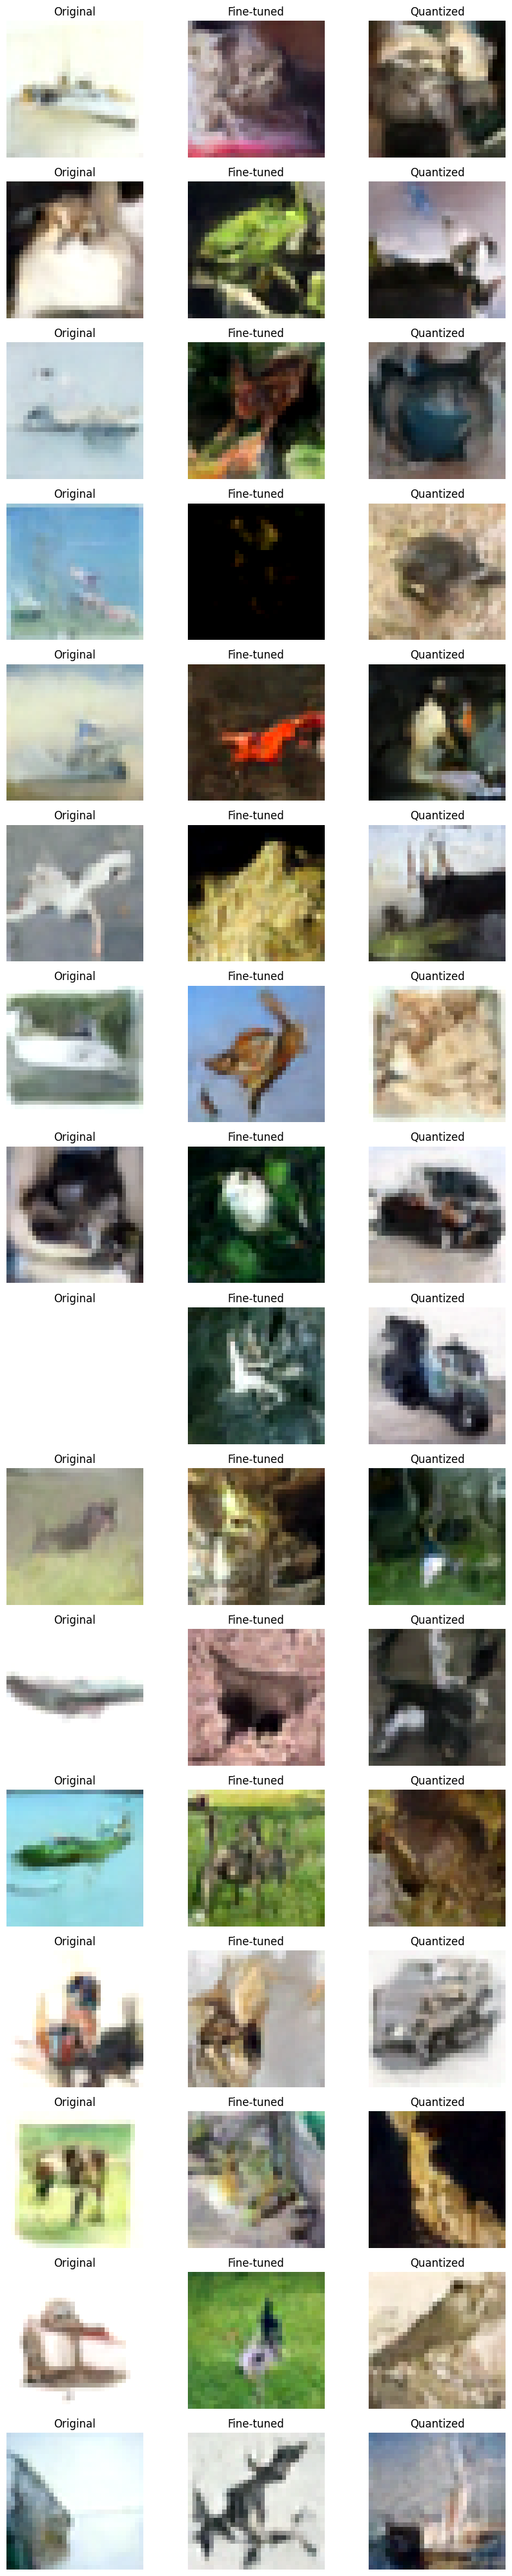

In [62]:
compare_samples(
    samples_original,
    samples_finetuned,
    samples_quantized
)